In [1]:
#setup
from mlwpy import *
diabetes = datasets.load_diabetes()
%matplotlib inline

In [2]:
N = 20
ftr = np.linspace(-10,10,num= N) #ftr values
tgt = 2 * ftr**2 - 3 + np.random.uniform(-2,2,N) #tgt = func(ftr)

(train_ftr,test_ftr,train_tgt,test_tgt) = skms.train_test_split(ftr,tgt,test_size=N//2)

display(pd.DataFrame({"ftr":train_ftr,"tgt":train_tgt}).T)
                            

,0,1,2,3,4,5,6,7,8,9
ftr,-1.5789,-6.8421,-3.6842,1.5789,-7.8947,3.6842,7.8947,4.7368,5.7895,-0.5263
tgt,2.3906,91.0234,22.3791,3.8658,122.5817,22.9962,121.7528,40.6026,62.7696,-1.6137


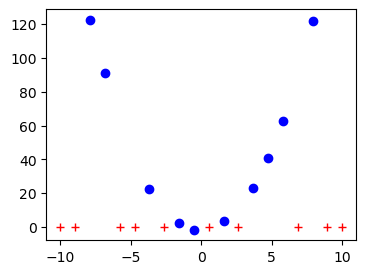

In [3]:
plt.plot(train_ftr,train_tgt, 'bo')
plt.plot(test_ftr, np.zeros_like(test_ftr), 'r+')

In [4]:
#now we will reshape since sklearn wants 2D shape
sk_model = linear_model.LinearRegression()
sk_model.fit(train_ftr.reshape(-1,1),train_tgt)
sk_preds = sk_model.predict(test_ftr.reshape(-1,1))
sk_preds[:3]

array([53.218 , 41.4552, 56.8374])

In [5]:
#fit-predit evaluate a 1D po;ynomial (a line)
model_one = np.poly1d(np.polyfit(train_ftr,train_tgt,1))
preds_one = model_one(test_ftr)
print(preds_one[:3])

[53.218  41.4552 56.8374]


In [6]:
#the predictions come back to the same
print("all close?",np.allclose(sk_preds,preds_one))

#lets use mean square error to check if they actually align
mse = metrics.mean_squared_error
print("RMSE:",np.sqrt(mse(test_tgt,preds_one)))

all close? True
RMSE: 86.69151817350722


In [7]:
#now lets try with polynomial model with 2 degree
model_two = np.poly1d(np.polyfit(train_ftr,train_tgt,2))
preds_two = model_two(test_ftr)
print("RMSE:",np.sqrt(mse(test_tgt,preds_two)))

RMSE: 1.276599218888112


In [8]:
model_three = np.poly1d(np.polyfit(train_ftr,train_tgt,9))
preds_three = model_three(test_ftr)
print("RMSE:",np.sqrt(mse(test_tgt,preds_three)))

RMSE: 317.36344242359115


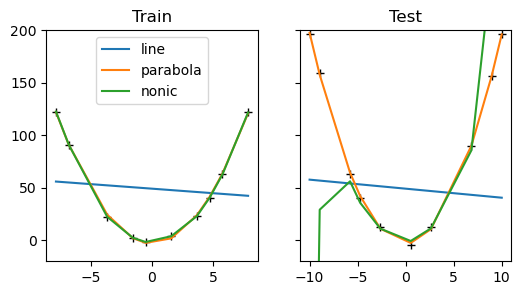

In [9]:
fig,axes = plt.subplots(1,2,figsize= (6,3),sharey= True)

labels = ['line','parabola','nonic']
models = [model_one, model_two, model_three]
train = (train_ftr,train_tgt)
test = (test_ftr, test_tgt)

for ax, (ftr,tgt) in zip(axes, [train,test]):
    ax.plot(ftr,tgt,'k+')
    for m, lbl in zip(models,labels):
        ftr = sorted(ftr)
        ax.plot(ftr,m(ftr),'-',label=lbl)



axes[1].set_ylim(-20,200)
axes[0].set_title("Train")
axes[1].set_title("Test")
axes[0].legend(loc='upper center');


In [10]:
results = []
for complexity in [1,2,6,9]:
    model=np.poly1d(np.polyfit(train_ftr,train_tgt,complexity))
    train_error = np.sqrt(mse(train_tgt,model(train_ftr)))
    test_error = np.sqrt(mse(test_tgt,model(test_ftr)))
    results.append((complexity,train_error,test_error))
columns = ["Complexity","Train Error","Test Error"]
results_df = pd.DataFrame.from_records(results,columns = columns, index="Complexity")
results_df

,Train Error,Test Error
Complexity,,
1,45.4951,86.6915
2,1.0828,1.2766
6,0.2819,6.1417
9,0.0000,317.3634


<Axes: xlabel='Complexity'>

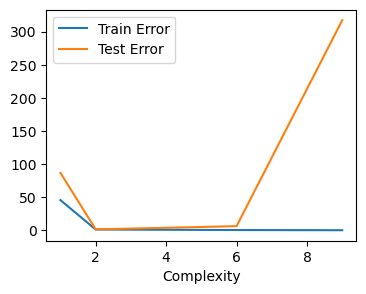

In [11]:
results_df.plot()

In [12]:
def training_loss(loss,model, training_data):
    ' total training_loss on train_data with model under loss'
    return sum(loss(model.predict(x.reshape(1,-1)),y)
                            for x,y in training_data)\

def squared_error(prediction,actual):
    'squared error on as single example'
    return (prediction-actual)**2

#could be used like
#my_training_loss = training_loss(squared_error, model, training_data)

In [13]:
knn = neighbors.KNeighborsRegressor(n_neighbors=3)
fit = knn.fit(diabetes.data, diabetes.target)

training_data = zip(diabetes.data,diabetes.target)

my_training_loss = training_loss(squared_error, knn, training_data)

print(my_training_loss)

[863792.3333]


In [14]:
mse = metrics.mean_squared_error(diabetes.target, knn.predict(diabetes.data))

print(mse*len(diabetes.data))

863792.3333333333


In [15]:
def complexity(model):
    return model.complexity

def cost(model,training_data,_lambda,loss):
    return training_loss(m,D) + _lambda*complexity(m)

In [16]:
model = neighbors.KNeighborsRegressor(10)
skms.cross_val_score(
    model,
    diabetes.data,
    diabetes.target,
    cv=5,
    scoring = 'neg_mean_squared_error'
)

#notes
#defaults for cross_val_score are
# cv=3 fold, no shuffle, stratified if classifier
# model.score by default (regressors: r2, classifiers: accuracy)

array([-3206.7542, -3426.4313, -3587.9422, -3039.4944, -3282.6016])

In [17]:
iris = datasets.load_iris()
model = neighbors.KNeighborsClassifier(10)
skms.cross_val_score(model,iris.data,iris.target,cv = 5)

array([0.9667, 1.    , 1.    , 0.9333, 1.    ])

In [18]:
pet = np.array(['cat','dog','cat',
               'dog','dog','dog'])
list_folds = list(skms.KFold(2).split(pet))
training_idxs = np.array(list_folds)[:,0,:]
print(pet[training_idxs])

[['dog' 'dog' 'dog']
 ['cat' 'dog' 'cat']]


In [19]:
pet = np.array(['cat','dog','cat',
               'dog','dog','dog'])
idxs = np.array(list(skms.StratifiedKFold(2).split(np.ones_like(pet),pet)))
training_idxs = idxs[:,0,:]
print(pet[training_idxs])

[['cat' 'dog' 'dog']
 ['cat' 'dog' 'dog']]


In [20]:
iris = datasets.load_iris()
model = neighbors.KNeighborsClassifier(5)
non_strat_kf = skms.KFold(5)
skms.cross_val_score(model,iris.data,iris.target,cv = non_strat_kf)

array([1.    , 1.    , 0.8333, 0.9333, 0.8   ])

In [21]:
linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()

scores = []
for r in range(10):
    tts = skms.train_test_split(diabetes.data,diabetes.target,test_size = 0.25)
    (diabetes_train_ftrs,diabetes_test_ftrs,diabetes_train_tgt,diabetes_test_tgt) = tts

    fit = linreg.fit(diabetes_train_ftrs,diabetes_train_tgt)
    preds= fit.predict(diabetes_test_ftrs)

    score = metrics.mean_squared_error(diabetes_test_tgt,preds)
    scores.append(score)

scores = pd.Series(np.sqrt(sorted(scores)))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'
display(df.T)

Repeat,0,1,2,3,4,5,6,7,8,9
RMSE,49.0031,50.1913,51.9735,52.0722,53.2003,55.7007,56.2542,57.4919,58.6383,58.6942


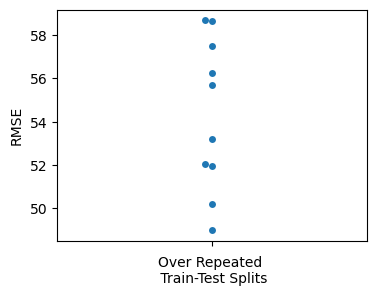

In [22]:
ax = plt.figure(figsize=(4,3)).gca()
sns.swarmplot(y='RMSE',data= df,ax=ax)
ax.set_xlabel('Over Repeated \n Train-Test Splits');

In [23]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
RMSE,10.0000,54.3220,3.5059,49.0031,51.9982,54.4505,57.1825,58.6942


In [24]:
def tts_fit_score(model,data,msr,test_size = .25):
    tts = skms.train_test_split(data.data,data.target,test_size=test_size)
    (train_ftrs,test_ftrs,train_tgt,test_tgt)= tts
    fit = linreg.fit(train_ftrs,train_tgt)
    preds = fit.predict(test_ftrs)
    score=msr(test_tgt,preds)
    return score

linreg= linear_model.LinearRegression()
diabetes = datasets.load_diabetes()
scores = [tts_fit_score(linreg,diabetes,metrics.mean_squared_error) for i in range(10)]
print(np.mean(scores))

3052.548205801788


,count,mean,std,min,25%,50%,75%,max
RMSE,10.0000,55.4388,3.5870,50.1900,52.9661,55.3965,58.3912,60.5431


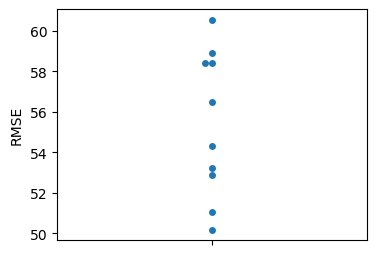

In [25]:
linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()

#non_default cv= argument
ss = skms.ShuffleSplit(test_size=.25)
scores = skms.cross_val_score(linreg,diabetes.data,diabetes.target, cv = ss, scoring='neg_mean_squared_error')

scores = pd.Series(np.sqrt(-scores))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'
display(df.describe().T)

ax = sns.swarmplot(y='RMSE',data=df)
ax.set_xlabel = ('Over repeated \n TrainTest Splits')

In [26]:
ss = skms.ShuffleSplit(test_size = .25, random_state = 42)

train,test = 0,1
next(ss.split(diabetes.data))[train][:10]

array([ 16, 408, 432, 316,   3,  18, 355,  60, 398, 124])

In [27]:
ss = skms.ShuffleSplit(test_size = .25, random_state=42)
next(ss.split(diabetes.data))[train][:10]

array([ 16, 408, 432, 316,   3,  18, 355,  60, 398, 124])

In [28]:
kf = skms.KFold(5)
next(kf.split(diabetes.data))[train][:10]

array([89, 90, 91, 92, 93, 94, 95, 96, 97, 98])

In [29]:
kf = skms.KFold(5)
next(kf.split(diabetes.data))[train][:10]

array([89, 90, 91, 92, 93, 94, 95, 96, 97, 98])

In [30]:
pet = np.array(['cat','dog','cat',
               'dog','dog','dog'])
kf = skms.KFold(3,shuffle = True)

train,test = 0,1

split_1_group_1 = next(kf.split(pet))[train]
split_2_group_1 = next(kf.split(pet))[train]

print(split_1_group_1, split_2_group_1)

[0 1 4 5] [0 1 3 5]


In [31]:
kf = skms.KFold(3,shuffle = True,random_state = 42)


split_1_group_1 = next(kf.split(pet))[train]
split_2_group_1 = next(kf.split(pet))[train]

print(split_1_group_1, split_2_group_1)

[2 3 4 5] [2 3 4 5]


,count,mean,std,min,25%,50%,75%,max
RMSE,442.0000,44.3557,32.1973,0.2086,18.4853,39.5482,63.9743,158.2330


Text(0.5, 17.722222222222214, 'OVER loo \n Train-Test_splits')

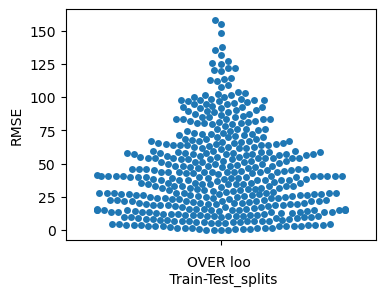

In [32]:
#Leave one out cross-validation

linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()

loo = skms.LeaveOneOut()
scores = skms.cross_val_score(linreg, diabetes.data, diabetes.target, cv = loo, scoring = 'neg_mean_squared_error')

scores = pd.Series(np.sqrt(-scores))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'

display(df.describe().T)

ax = sns.swarmplot(y='RMSE', data=df)
ax.set_xlabel('OVER loo \n Train-Test_splits')

In [35]:
#how much data do we need?
iris = datasets.load_iris()

# 10 data set sizes:  10% - 100% 
# (that much data is piped to a 5-fold CV)
train_sizes = np.linspace(.1,1.0,10)
nn = neighbors.KNeighborsClassifier()

(train_N, 
 train_scores, 
 test_scores) = skms.learning_curve(nn, 
                                    iris.data, iris.target, 
                                    cv=5, 
                                    train_sizes=train_sizes)

# collapse across the 5 CV scores; one result for each data set size
df = pd.DataFrame(test_scores, index=(train_sizes*100).astype(np.int64))
df['Mean 5-CV'] = df.mean(axis='columns')
df.index.name = "% Data Used"

display(df)

,0,1,2,3,4,Mean 5-CV
% Data Used,,,,,,
10,0.3333,0.3333,0.3333,0.3333,0.3333,0.3333
20,0.3333,0.3333,0.3333,0.3333,0.3333,0.3333
30,0.3333,0.3333,0.3333,0.3333,0.3333,0.3333
40,0.6667,0.6667,0.6667,0.6667,0.6667,0.6667
50,0.6667,0.6667,0.6667,0.6667,0.6667,0.6667
60,0.6667,0.6667,0.6667,0.6667,0.6667,0.6667
70,0.9333,0.8000,0.8333,0.8667,0.8000,0.8467
80,0.9667,0.9333,0.9000,0.9000,0.9667,0.9333
90,0.9667,1.0000,0.9000,0.9667,1.0000,0.9667


In [42]:

neat_sizes = (train_sizes*100).astype(np.int64)
labels = np_cartesian_product(neat_sizes, [0,1], np.arange(5))
score = np.concatenate([train_scores.flatten(), 
                        test_scores.flatten()], axis=0)
assert len(score) == len(labels)

df = pd.DataFrame.from_records(labels)
df.columns = ['pct', 'set', 'fold']
df.set = df.set.replace({0:'Train', 1:'Test'})
df['score'] = score


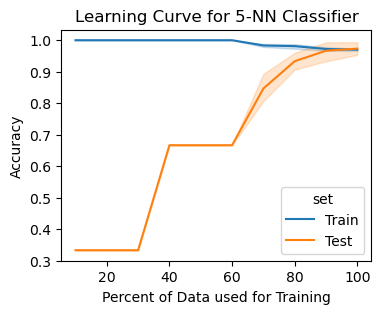

In [43]:
ax = sns.lineplot(x='pct', y='score', hue='set', data=df)

ax.set_title("Learning Curve for 5-NN Classifier")
ax.set_xlabel("Percent of Data used for Training")
ax.set_ylabel("Accuracy");

In [44]:

# tidying the numpy array is a bit of a pain
# xarray is designed to do this "natively" but
# i don't want to introduce that dependency
# [seems like there could be a better broadcasting 
#  solution to this]
def sk_graph_to_tidy(train_test_scores, # y values
                     eval_points,       # x values
                     eval_label,        # x column name
                     num_folds):        # could be inferred
    train_scores, test_scores = train_test_scores
    # humph, didn't know np_cartesian was order sensitive
    labels = np_cartesian_product(eval_points, 
                                  [0,1], # surrogates for train/test 
                                  np.arange(num_folds))
    score = np.concatenate([train_scores.flatten(), 
                            test_scores.flatten()], axis=0)
    
    df = pd.DataFrame.from_records(labels)
    df.columns = [eval_label, 'set', 'fold']
    df.set = df.set.replace({0:'Train', 1:'Test'})
    df['score'] = score
    return df

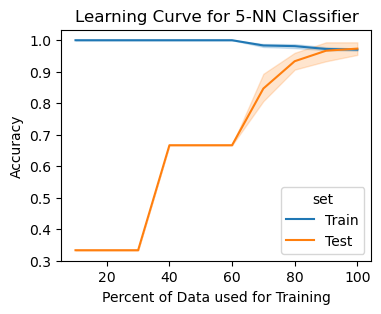

In [46]:
neat_sizes = (train_sizes*100).astype(np.int64)
tidy_df = sk_graph_to_tidy([train_scores, test_scores],
                           neat_sizes, 'pct', 5)

ax = sns.lineplot(x='pct', y='score', hue='set', data=tidy_df)

ax.set_title("Learning Curve for 5-NN Classifier")
ax.set_xlabel("Percent of Data used for Training")
ax.set_ylabel("Accuracy");

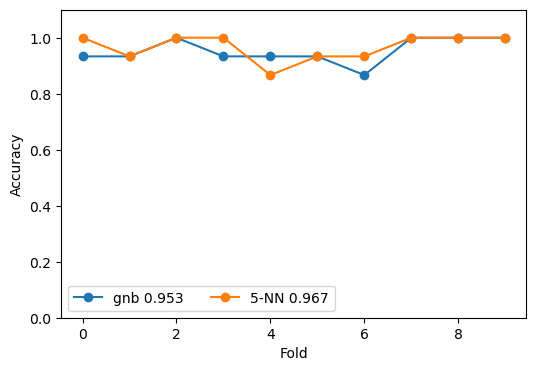

In [54]:
#comparing learners with cross validation

classifiers = {
    'gnb':naive_bayes.GaussianNB(),
    '5-NN':neighbors.KNeighborsClassifier(n_neighbors=5)
}

iris = datasets.load_iris()
fig,ax = plt.subplots(figsize=(6,4))

for name,model in classifiers.items():
    val_scores = skms.cross_val_score(model,iris.data,iris.target,cv=10,scoring='accuracy',n_jobs=-1) #use all cores
    my_lbl = "{} {:.3f}".format(name,val_scores.mean())
    ax.plot(val_scores, '-o', label=my_lbl)

ax.set_ylim(0,1.1)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Fold')
ax.legend(ncol=2)

    